**THE SCENARIO —** THE CHIEF DATA SCIENTIST'S DILEMMA

You are the Chief Data Scientist at HealthGuard AI. Your team has developed a model to predict whether a patient has a rare but serious disease.

The model's initial reports show 99% accuracy. Your CEO is thrilled and wants to deploy it immediately. However, you suspect something is wrong. You realize that in your town, only 1 in 100 people actually has the disease.

The Golden Rule: Building a model is like studying for an exam. Evaluation is taking the exam to see how well you actually learned. Different problems need different "Exams" (Metrics).

**THE ACCURACY PARADOX**

Why simple accuracy fails

The "Lazy" Model Scenario
Imagine a model that simply predicts "Healthy (0)" for everyone without looking at any data.

| Patient ID | Actual Diagnosis | Model Prediction | Check   |
| ---------- | ---------------- | ---------------- | ------- |
| #1         | Healthy (0)      | Healthy (0)      | Correct |
| #2         | Healthy (0)      | Healthy (0)      | Correct |
| #3         | Healthy (0)      | Healthy (0)      | Correct |
| #4         | Healthy (0)      | Healthy (0)      | Correct |
| #5         | Healthy (0)      | Healthy (0)      | Correct |
| #6         | Healthy (0)      | Healthy (0)      | Correct |
| #7         | Healthy (0)      | Healthy (0)      | Correct |
| #8         | Healthy (0)      | Healthy (0)      | Correct |
| #9         | Sick (1)         | Healthy (0)      | WRONG   |
| #10        | Sick (1)         | Healthy (0)      | WRONG   |


**Reflection Task:** If 8 out of 10 patients are healthy, and the model predicts "Healthy" for everyone:

What is the Accuracy? __________________________

Is this model useful for finding sick patients? _______________

****
****

**PART 1: THE CONFUSION MATRIX**
Sorting Truth from Lies

The **Confusion Matrix** is a table used to describe the performance of a classification model.

|                 | Predicted: NO       | Predicted: YES      |
| --------------- | ------------------- | ------------------- |
| **Actual: NO**  | True Negative (TN)  | False Positive (FP) |
| **Actual: YES** | False Negative (FN) | True Positive (TP)  |


**Exercise 1: Coding the Matrix**
- Run the code below to see how a confusion matrix is generated using scikit-learn.

[[7 0]
 [2 1]]


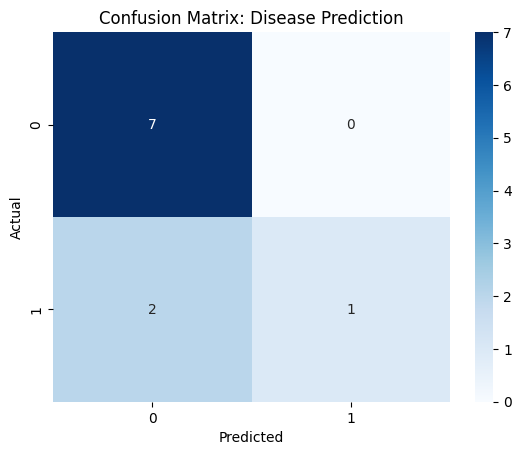

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Actual values and Model Predictions
y_true = [0, 0, 0, 0, 0, 1, 1, 0, 0, 1]
y_pred = [0, 0, 0, 0, 0, 0, 1, 0, 0, 0] # Model missed most sick people!

#Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

#print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Disease Prediction')
plt.show()

Task: Based on the output, identify:


False Positives (Type I Error): ________________ (The "False Alarm")


False Negatives (Type II Error): ________________ (The "Missed Danger

****
****

**PART 2: REGRESSION METRICS (PREDICTING NUMBERS)**

**The Scenario:** You are now predicting house prices for UrbanPrice Analytics. You want your predictions to be as close to the actual "Bullseye" as possible.

**The "Darts Game" Analogy**
In regression, we don't just care if we were "right" or "wrong"—we care about how far off we were.

| House        | Actual Price (y) | Predicted Price (ŷ) | Error (y − ŷ) | Squared Error (y − ŷ)² |
| ------------ | ---------------- | ------------------- | ------------- | ---------------------- |
| #1           | 100k             | 90k                 | 10            | 100                    |
| #2           | 150k             | 170k                | -20           | 400                    |
| #5 (Outlier) | 500k             | 400k                | 100           | 10,000                 |


**1. Mean Absolute Error (MAE)**
The average of the absolute distances from the truth.

- Formula: $\frac{1}{n}\sum|y-\hat{y}|$
- Insight: MAE is robust and "ignores" the extreme impact of outliers.



**2. Mean Squared Error (MSE)**
The average of the squared errors.
  - Formula: $\frac{1}{n}\sum(y-\hat{y})^2$
  - Insight: Because errors are squared, large misses (like House #5) are punished heavily.

**3. Root Mean Squared Error (RMSE)**
  - The square root of MSE
  - Why use it? MSE results are in "Units Squared" (e.g., Dollars²), which humans can't easily visualize. RMSE brings the penalty back to real units ($ Dollars).

**4. $R^2$ (R-Squared) - The "Fitness" Score**
  - This tells you what percentage of the total variation is explained by your model.
    - The Logic: If you knew nothing, you'd just guess the Average Price for every house16. $R^2$ tells you how much better your model is than just guessing the average.
    - Scale: 0.0 (Worst) to 1.0 (Perfect).

**Practical Coding Task:** Calculating Regression Metrics

- Run this block to calculate these metrics for the "UrbanPrice" house data from your worksheet.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Data from the worksheet
actual_prices = np.array([100, 150, 200, 250, 500])
predicted_prices = np.array([90, 170, 180, 240, 400])

#Mean absolute error
mae = mean_absolute_error(actual_prices, predicted_prices)

#Mean squared error
mse = mean_squared_error(actual_prices, predicted_prices)

#Root mean squared error
rmse = np.sqrt(mse)

#R2-score
r2 = r2_score(actual_prices, predicted_prices)

#print(f"Mean Absolute Error (MAE): {mae}")                   # Worksheet value: 32 [cite: 64]
#print(f"Mean Squared Error (MSE): {mse}")                   # Worksheet value: 2200 [cite: 66]
#print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")        # Worksheet value: ~46.9 [cite: 68]
#print(f"R-Squared Score: {r2:.2f}")                         # Worksheet value: ~0.88 [cite: 80]

Mean Absolute Error (MAE): 32.0
Mean Squared Error (MSE): 2200.0
Root Mean Squared Error (RMSE): 46.90
R-Squared Score: 0.89


**Quick Check:** If your model has an $R^2$ of 0.88, it means your model explained 88% of the total variation in house prices.

****
****

**PART 3: BIAS VS. VARIANCE**
- The "Bullseye" Analogy

- High Bias (Underfitting): The model is too simple. It’s like a student who only learns one formula and tries to use it for every question.

- High Variance (Overfitting): The model is too complex. It memorizes the "noise" or flukes in the data instead of the actual pattern

| Problem      | Description                                          | Cause                |
| ------------ | ---------------------------------------------------- | -------------------- |
| Underfitting | Performs poorly on both Train & Test data            | Model is too simple  |
| Overfitting  | Performs great on Train data, but fails on Test data | Model is too complex |


****
****

**PART 4: MODEL VALIDATION (CROSS-VALIDATION)**

- The Analogy: "The Rotation Policy"
  - Instead of testing on the same chapter every time, rotating the chapters ensures you know the whole book.
  
  - K-Fold Cross Validation
    - In K=5 fold validation, the data is split into 5 parts. We train 5 times, each time using a different part as the "Test Set" and the rest as "Train Set"

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Sample data
X = np.random.rand(100, 2)
y = np.random.randint(0, 2, 100)

#Define model
model = LogisticRegression()

#Cross validation scores
scores = cross_val_score(model, X, y, cv=5)

print(f"Scores for each fold: {scores}")
print(f"Average Accuracy: {scores.mean():.2f}")

Scores for each fold: [0.5  0.55 0.55 0.5  0.45]
Average Accuracy: 0.51


**FINAL CHALLENGE**

**Scenario:** You are building a model for Bank Fraud Detection.

- Which error is worse: A False Positive (flagging a real transaction as fraud) or a False Negative (letting a thief steal money)? _________________________________________________________

- If your training accuracy is 98% but your test accuracy is 65%, is your model suffering from High Bias or High Variance? _________________________________________________________